In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [3]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64663 entries, 0 to 64662
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      64662 non-null  float64
 1   miktar                      52485 non-null  float64
 2   markalar                    62414 non-null  object 
 3   alerjenler                  64663 non-null  object 
 4   eser_miktarlar              64663 non-null  object 
 5   icerik_sayisi               56569 non-null  float64
 6   nutriscore_notu             64604 non-null  object 
 7   nova_grubu                  55315 non-null  float64
 8   yesil_skor_notu             48007 non-null  object 
 9   palmiye_yagi_icermez        52774 non-null  object 
 10  vejetaryen                  50318 non-null  object 
 11  vegan_durumu                56899 non-null  object 
 12  enerji_kcal                 64050 non-null  float64
 13  yag_g                       640

In [5]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,6.466200e+04,5.248500e+04,56569.000000,55315.000000,64050.000000,64046.000000,63371.000000,63993.000000,63752.000000,45823.000000,64042.000000,64172.000000,3203.000000,18707.000000
mean,6.010123e+12,1.322393e+08,13.082908,3.101437,269.949602,14.179282,4.700736,26.647547,10.130726,3.245956,7.514401,6.748853,4.993035,14.102474
std,4.012318e+14,2.629521e+10,13.437641,1.153712,390.455067,33.355534,8.591483,29.333040,20.687990,4.977845,9.292548,1405.340677,19.851106,30.849711
min,1.526000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,-1.217330
25%,3.256226e+12,5.000000e+01,4.000000,3.000000,76.000000,1.000000,0.200000,4.000000,0.500000,0.400000,1.600000,0.030000,0.000000,0.000000
50%,4.012359e+12,2.000000e+02,10.000000,4.000000,232.000000,5.300000,1.300000,12.900000,3.200000,1.900000,5.900000,0.300000,0.000000,0.000000
75%,5.942204e+12,4.000000e+02,18.000000,4.000000,409.000000,20.100000,5.700000,52.000000,10.800000,4.400000,10.000000,0.984252,0.000000,8.437500
max,1.020304e+17,5.940568e+12,405.000000,4.000000,49328.000000,5856.650000,450.000000,1900.000000,1700.000000,375.000000,800.000000,355942.500000,100.000000,449.400000


In [6]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
21416,7.310868e+12,1.5,hjordnära skånemejerier,['Milk'],[],3.0,B,1.0,C,False,True,no,45.0,1.5,1.0,4.9,4.9,NaN,3.5,0.0975,NaN,0.000000,l,"['Beverages and beverages preparations', 'Beve...",[]
54617,2.001621e+07,160.0,lidl,"['Gluten', 'Milk']",[],11.0,E,3.0,B,True,True,no,528.0,29.5,17.2,61.8,17.7,1.3,4.4,0.6100,NaN,NaN,g,"['Snacks', 'Sweet snacks', 'Biscuits and cakes...",[]
48158,2.000003e+12,NaN,NaN,[],[],NaN,D,NaN,NaN,NaN,NaN,NaN,284.0,0.3,0.1,70.0,65.5,5.5,2.0,0.0000,NaN,NaN,NaN,"['Plant-based foods and beverages', 'Plant-bas...",[]
1541,3.270161e+12,2.0,picard,[],[],4.0,A,1.0,A,True,True,yes,40.0,0.5,0.1,3.6,1.9,3.2,3.6,0.0100,NaN,NaN,parts,"['Plant-based foods and beverages', 'Plant-bas...","['Low or no salt', 'Organic', 'EU Organic', 'F..."
36963,3.596710e+12,0.3,auchan,"['Celery', 'Gluten', 'Soybeans']","['Crustaceans', 'Eggs', 'Fish', 'Milk', 'Mollu...",62.0,C,4.0,NaN,NaN,False,no,143.0,6.2,2.0,15.0,3.3,1.5,5.6,0.7600,NaN,24.814216,kg,"['Meals', 'Frozen foods', 'Savory semolina dis...","['Nutriscore', 'Nutriscore Grade B']"


In [7]:
data.isnull().mean() * 100

barkod                         0.001546
miktar                        18.833027
markalar                       3.478032
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                 12.517205
nutriscore_notu                0.091242
nova_grubu                    14.456490
yesil_skor_notu               25.758162
palmiye_yagi_icermez          18.386094
vejetaryen                    22.184248
vegan_durumu                  12.006866
enerji_kcal                    0.947992
yag_g                          0.954178
doymus_yag_g                   1.998051
karbonhidrat_g                 1.036141
seker_g                        1.408843
lif_g                         29.135673
protein_g                      0.960364
tuz_g                          0.759321
alkol_yuzde                   95.046626
meyve_sebze_baklagil_yuzde    71.070009
birim                         20.784684
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [8]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (64461): ['1.020304050607081e+17', '1000029852900.0', '10001219.0', '10001295.0', '10001356.0', '10001400.0', '10001404.0', '10001691.0', '10001707.0', '10001875.0'] ...
miktar (1143): ['0.0', '0.03', '0.042', '0.045', '0.046', '0.05', '0.055', '0.06', '0.065', '0.07'] ...
markalar (12450): ['"tradition culinaire"', "'z bregov", '(sans marque)', '07x netto 03.25', '1 2 3 fruits', '1 attimo in forma', '1 l', '1 x auer 01.25', '1%', '1-2-3'] ...
alerjenler (1836): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Celery', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur dioxide and sulphites']", "['Apple', 'Banana', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Kiwi', 'Orange', 'Peach']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Banana', 'Orange', 'Sulphur dioxide and sulphites']"] ...
eser_miktarlar (2420): ["['07

In [9]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                 9052
Soybeans                                             6997
Milk                                                 5739
Gluten                                               4450
Eggs                                                 3991
Sesame seeds                                         3959
Mustard                                              3518
Peanuts                                              2579
Celery                                               2271
Fish                                                 1237
Crustaceans                                          1084
Molluscs                                              933
Lupin                                                 746
Sulphur dioxide and sulphites                         521
Cereals-with-gluten                                    28
Crustaceans-and-shellfish                              26
En-nuts                  

In [10]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['etiketler_listesi']:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 500 ---")
    print(counts.head(500))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- etiketler_listesi - Top 500 ---
etiketler_listesi
Nutriscore                                              12960
Organic                                                  9893
Green Dot                                                8944
Vegetarian                                               8631
EU Organic                                               8357
Vegan                                                    6515
No gluten                                                6515
AB Agriculture Biologique                                4883
Nutriscore Grade A                                       4663
Triman                                                   4549
No preservatives                                         3593
Made in France                                           3487
EU Agriculture                                           2991
FR-BIO-01                                                2723
No added sugar                                           2618
Non-EU Agricultu

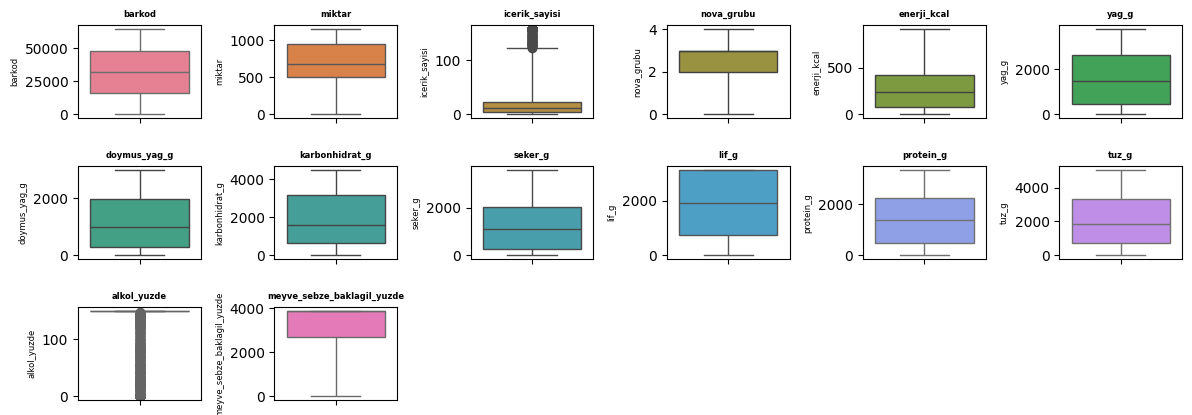

In [11]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

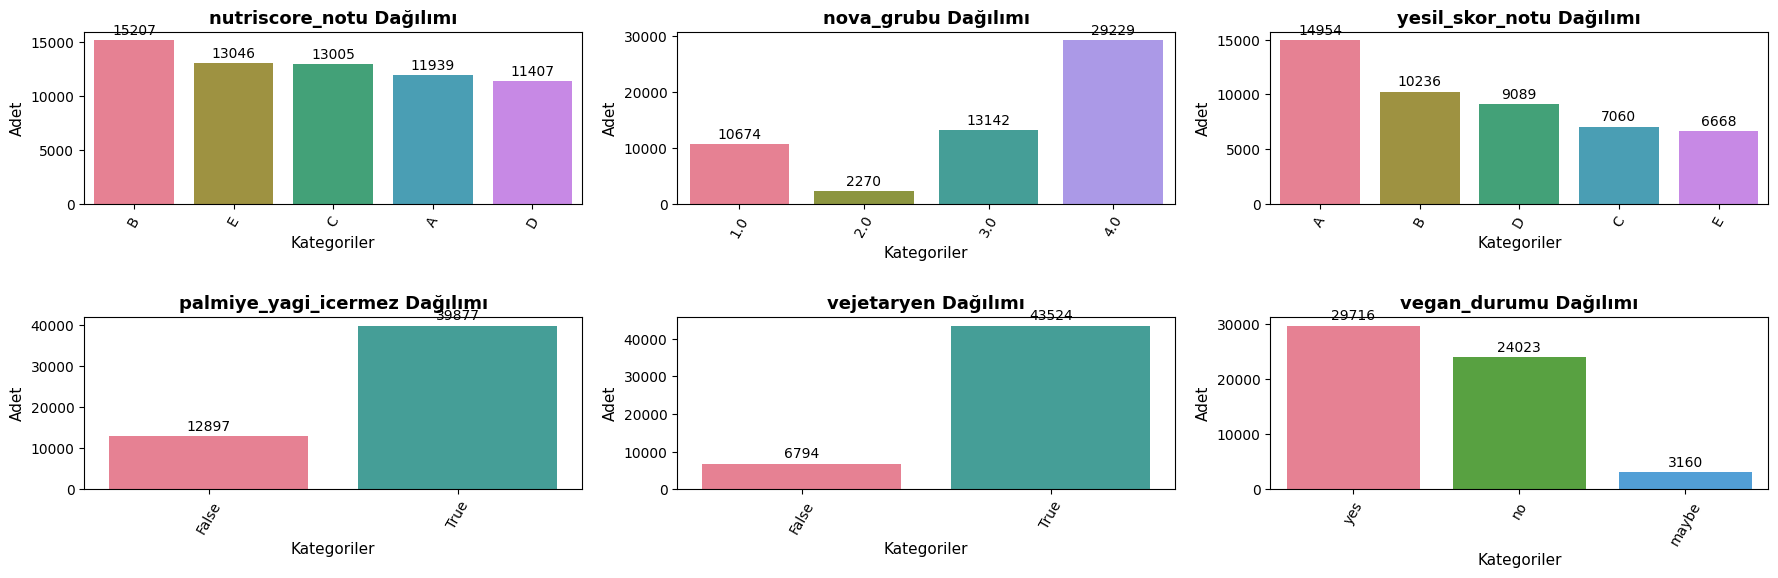

In [12]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()


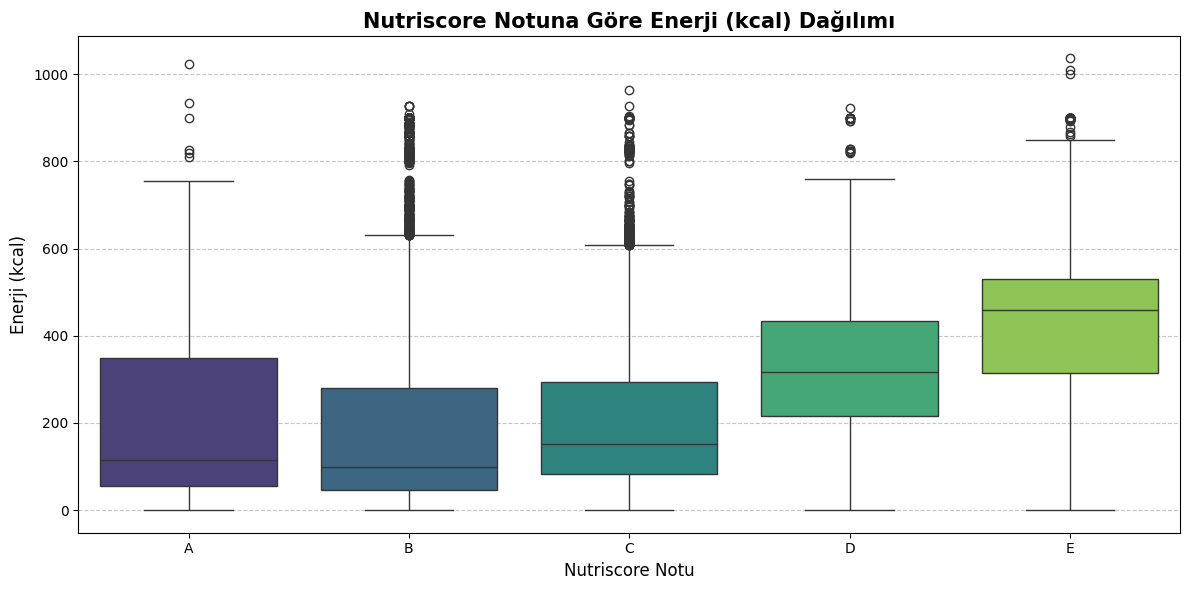

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlayalım
df_plot = data[['enerji_kcal', 'nutriscore_notu']].dropna()

# --- UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ) ---
Q1 = df_plot['enerji_kcal'].quantile(0.20)
Q3 = df_plot['enerji_kcal'].quantile(0.80)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sınırlar dışında kalan verileri temizleyelim
df_filtered = df_plot[(df_plot['enerji_kcal'] >= lower_bound) & (df_plot['enerji_kcal'] <= upper_bound)]
# ---------------------------------------------

# Nutriscore notlarını sıralı bir şekilde göstermek için liste tanımlayalım
nutriscore_order = ['A', 'B', 'C', 'D', 'E']

# Eğer veri setinizde bazı harfler yoksa mevcut olanları filtreleyelim
existing_scores = [score for score in nutriscore_order if score in df_filtered['nutriscore_notu'].unique()]

plt.figure(figsize=(12, 6))

# Boxplot çizimi (Temizlenmiş veri ile)
sns.boxplot(
    x='nutriscore_notu', 
    y='enerji_kcal', 
    data=df_filtered, 
    order=existing_scores, 
    palette='viridis'
)

# Grafik detayları
plt.title('Nutriscore Notuna Göre Enerji (kcal) Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Nutriscore Notu', fontsize=12)
plt.ylabel('Enerji (kcal)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafiği gösterme
plt.tight_layout()
plt.show()

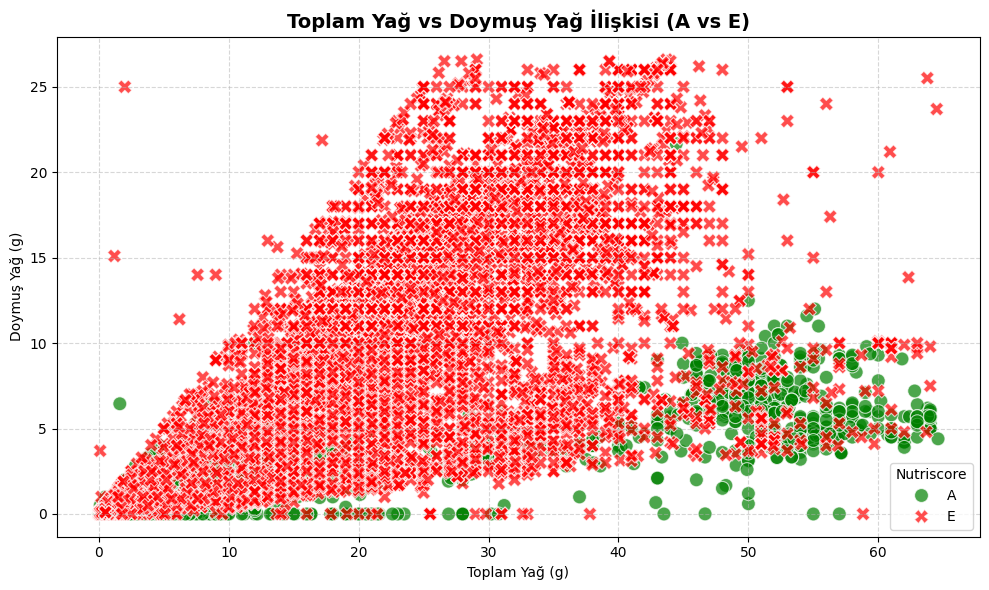

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi hazırlayalım
# Sadece 'A' ve 'E' olanları seçmek için isin() metodunu kullanıyoruz
df_clean = data.dropna(subset=['yag_g', 'doymus_yag_g', 'nutriscore_notu'])
df_clean = df_clean[(df_clean['yag_g'] > 0) & (df_clean['nutriscore_notu'].isin(['A', 'E']))].copy()

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ)
# Her iki sütun için de sınırlar belirleyip filtreleyelim
for col in ['yag_g', 'doymus_yag_g']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sınırların dışındaki verileri eleyelim
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

# 3. Görselleştirme
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean, 
    x='yag_g', 
    y='doymus_yag_g', 
    hue='nutriscore_notu', 
    hue_order=['A', 'E'], # Sadece A ve E'yi göster
    palette={'A': 'green', 'E': 'red'}, # A yeşil, E kırmızı olsun
    style='nutriscore_notu',
    s=100, # Nokta boyutu
    alpha=0.7
)

plt.title('Toplam Yağ vs Doymuş Yağ İlişkisi (A vs E)', fontsize=14, fontweight='bold')
plt.xlabel('Toplam Yağ (g)')
plt.ylabel('Doymuş Yağ (g)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Nutriscore')
plt.tight_layout()
plt.show()

Text(0.5, 0.92, 'Temizlenmiş 3D Besin Değerleri Dağılımı (A vs E)')

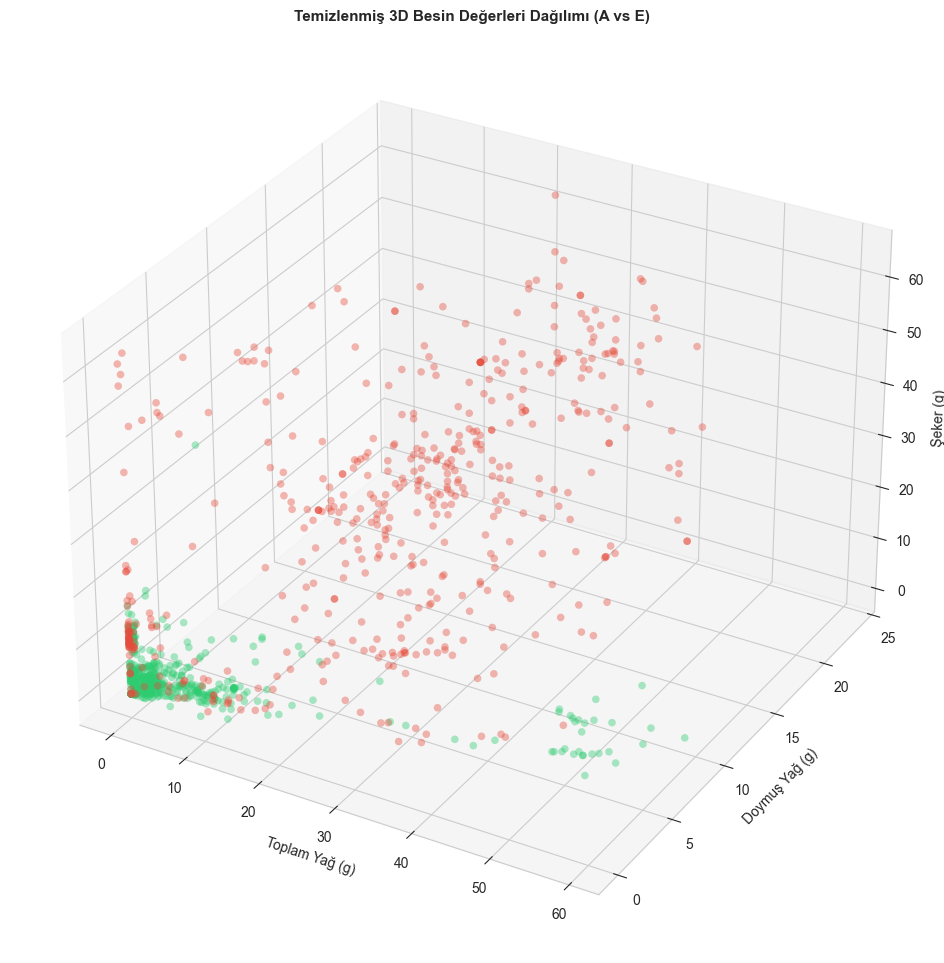

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 1. Veriyi hazırlayalım
df_3d = data.dropna(subset=['yag_g', 'doymus_yag_g', 'seker_g', 'nutriscore_notu'])
# Sadece A ve E'yi seç
df_3d = df_3d[df_3d['nutriscore_notu'].isin(['A', 'E'])].copy()

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR)
for col in ['yag_g', 'doymus_yag_g', 'seker_g']:
    Q1 = df_3d[col].quantile(0.25)
    Q3 = df_3d[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_3d = df_3d[(df_3d[col] >= lower_bound) & (df_3d[col] <= upper_bound)]

# --- [TEMİZLİK ADIMI]: ÖRNEKLEME (SAMPLING) ---
# Eğer veri hala çok yoğunsa, nokta sayısını azaltalım.
# max_points_per_group = 500 (Her grup için maksimum nokta)
num_A = min(len(df_3d[df_3d['nutriscore_notu'] == 'A']), 500)
num_E = min(len(df_3d[df_3d['nutriscore_notu'] == 'E']), 500)

df_sampled_A = df_3d[df_3d['nutriscore_notu'] == 'A'].sample(n=num_A, random_state=42)
df_sampled_E = df_3d[df_3d['nutriscore_notu'] == 'E'].sample(n=num_E, random_state=42)

# Temizlenmiş ve örneklenmiş veri seti
df_final = pd.concat([df_sampled_A, df_sampled_E])

# 3. Görselleştirme (Temizlenmiş Stille)
sns.set_style("whitegrid") # Beyaz grid arka plan
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Renkler: Daha soft (yumuşak) yeşil ve kırmızı tonları
colors = {'A': '#2ecc71', 'E': '#e74c3c'}

for score in ['A', 'E']:
    subset = df_final[df_final['nutriscore_notu'] == score]
    ax.scatter(
        subset['yag_g'], 
        subset['doymus_yag_g'], 
        subset['seker_g'], 
        c=colors[score], 
        label=f'Nutriscore {score}',
        s=30,      # Daha küçük nokta boyutu
        alpha=0.4, # Daha yüksek şeffaflık (arka arkaya gelenler yormasın)
        edgecolors='none' # Kenar çizgilerini kaldırdık
    )

# Eksen etiketleri ve görünüm ayarları
ax.set_xlabel('Toplam Yağ (g)', fontsize=10)
ax.set_ylabel('Doymuş Yağ (g)', fontsize=10)
ax.set_zlabel('Şeker (g)', fontsize=10)
ax.set_title('Temizlenmiş 3D Besin Değerleri Dağılımı (A vs E)', fontsize=11, fontweight='bold')

# Bakış açısını değiştirerek karmaşayı azaltabiliriz (isteğe bağlı)
# ax.view_init(elev=20, azim=135) # Yükseklik ve A


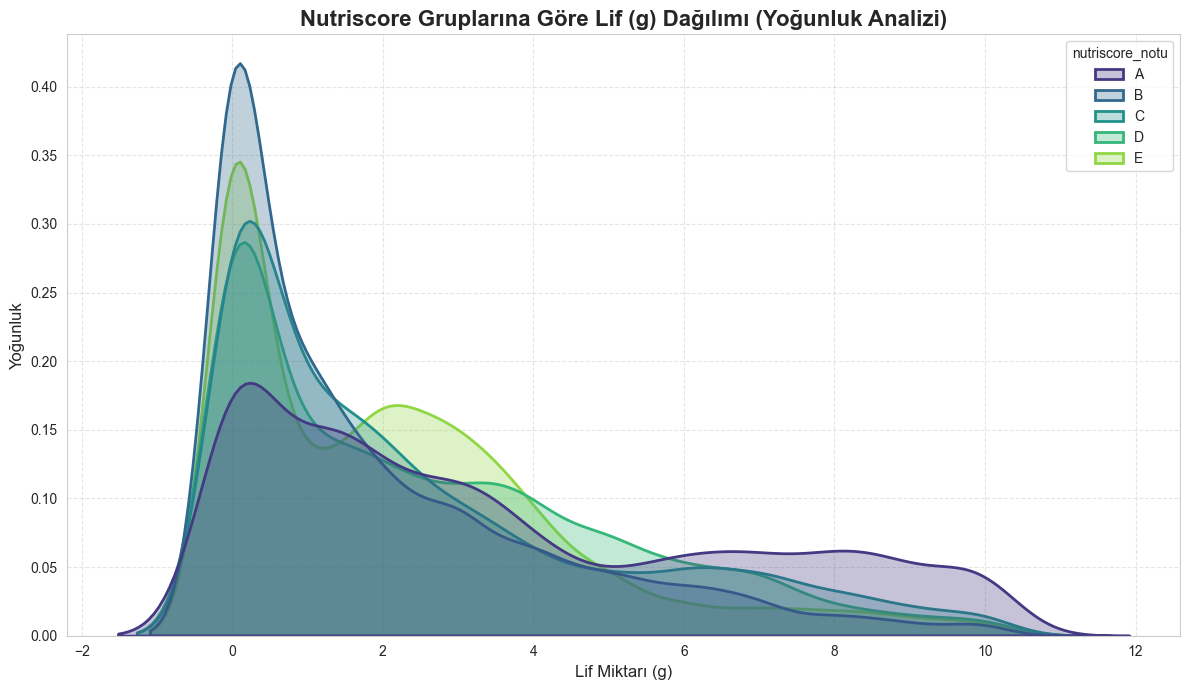

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlayalım
df_fiber = data[['lif_g', 'nutriscore_notu']].dropna()

# --- UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ) ---
# Grafiğin daha düzgün gözükmesi için aşırı yüksek lif değerlerini temizleyelim
Q1 = df_fiber['lif_g'].quantile(0.25)
Q3 = df_fiber['lif_g'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_fiber[(df_fiber['lif_g'] >= lower_bound) & (df_fiber['lif_g'] <= upper_bound)]

# Nutriscore sıralaması
nutriscore_order = ['A', 'B', 'C', 'D', 'E']

plt.figure(figsize=(12, 7))

# Yoğunluk (KDE) Grafiği
# common_norm=False: Her grubun kendi içindeki dağılımını daha net gösterir
sns.kdeplot(
    data=df_filtered, 
    x='lif_g', 
    hue='nutriscore_notu', 
    hue_order=nutriscore_order,
    fill=True, 
    alpha=0.3, # Şeffaflık
    linewidth=2,
    palette='viridis',
    common_norm=False
)

# Grafik detayları
plt.title('Nutriscore Gruplarına Göre Lif (g) Dağılımı (Yoğunluk Analizi)', fontsize=16, fontweight='bold')
plt.xlabel('Lif Miktarı (g)', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

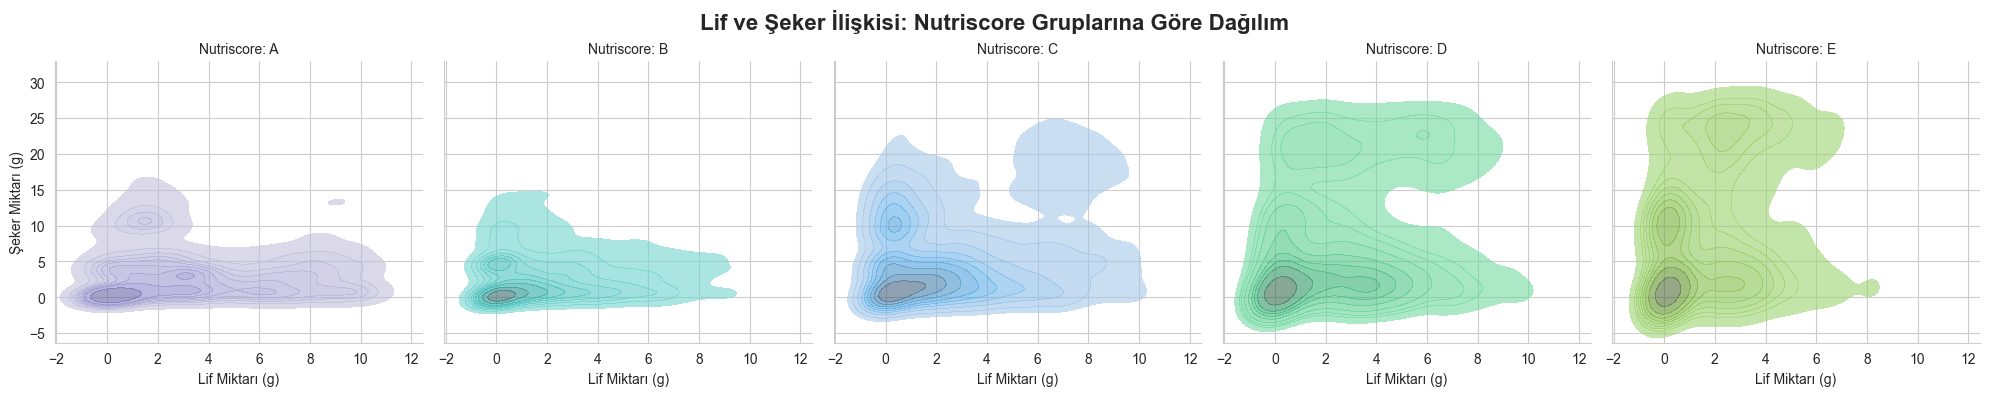

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi hazırlayalım
df_density = data.dropna(subset=['lif_g', 'seker_g', 'nutriscore_notu'])

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ)
# Lif ve Şeker için ayrı ayrı temizlik yapalım
for col in ['lif_g', 'seker_g']:
    Q1 = df_density[col].quantile(0.25)
    Q3 = df_density[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_density = df_density[(df_density[col] >= lower_bound) & (df_density[col] <= upper_bound)]

# 3. Görselleştirme (FacetGrid ile 2D Yoğunluk Haritası)
# Her Nutriscore grubu için ayrı bir "yoğunluk alanı" oluşturuyoruz
g = sns.FacetGrid(df_density, col="nutriscore_notu", col_order=['A', 'B', 'C', 'D', 'E'], 
                  hue="nutriscore_notu", palette="viridis", height=4, aspect=1)

# 2D KDE (Yoğunluk) grafiğini çiz
g.map_dataframe(sns.kdeplot, x="lif_g", y="seker_g", fill=True, alpha=0.6, thresh=0.05)

# 4. Profesyonel düzenlemeler
g.set_titles("Nutriscore: {col_name}")
g.set_axis_labels("Lif Miktarı (g)", "Şeker Miktarı (g)")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Lif ve Şeker İlişkisi: Nutriscore Gruplarına Göre Dağılım', fontsize=16, fontweight='bold')

plt.show()

In [18]:
data["kategori_listesi"].head(10)

0    ['Dairies', 'Fermented foods', 'Fermented milk...
1    ['Beverages and beverages preparations', 'Beve...
2    ['Beverages and beverages preparations', 'Beve...
3    ['Beverages and beverages preparations', 'Beve...
4    ['Beverages and beverages preparations', 'Beve...
5    ['Beverages and beverages preparations', 'Beve...
6    ['Beverages and beverages preparations', 'Beve...
7    ['Dairies', 'Fermented foods', 'Fermented milk...
8    ['Beverages and beverages preparations', 'Beve...
9    ['Dairies', 'Fermented foods', 'Fermented milk...
Name: kategori_listesi, dtype: object

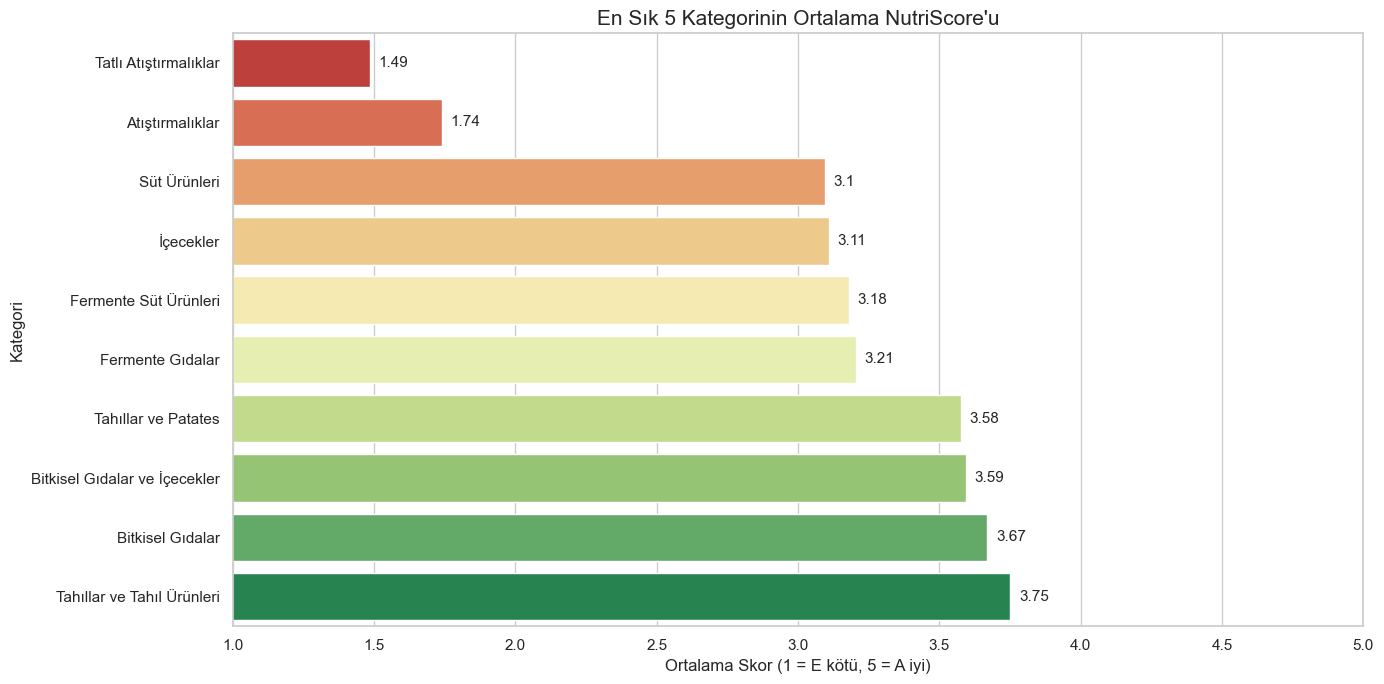

In [28]:
# Kategori isimlerini Türkçe / açıklamalı hale getir

kategori_map = {
    "Sweet snacks": "Tatlı Atıştırmalıklar",
    "Snacks": "Atıştırmalıklar",
    "Dairies": "Süt Ürünleri",
    "Beverages": "İçecekler",
    "Fermented milk products": "Fermente Süt Ürünleri",
    "Fermented foods": "Fermente Gıdalar",
    "Cereals and potatoes": "Tahıllar ve Patates",
    "Plant-based foods and beverages": "Bitkisel Gıdalar ve İçecekler",
    "Plant-based foods": "Bitkisel Gıdalar",
    "Cereals and their products": "Tahıllar ve Tahıl Ürünleri"
}
top_kategoriler = df["kategori"].value_counts().head(10).index
mean_scores = (
    df[df["kategori"].isin(top_kategoriler)]
    .groupby("kategori")["score_num"]
    .mean()
    .sort_values()
)


# mean_scores indexlerini değiştir
mean_scores_tr = mean_scores.copy()
mean_scores_tr.index = mean_scores_tr.index.map(
    lambda x: kategori_map[x] if x in kategori_map else x
)

# Grafik
plt.figure(figsize=(14,7))

sns.barplot(
    x=mean_scores_tr.values,
    y=mean_scores_tr.index,
    palette="RdYlGn"
)

plt.title("En Sık 5 Kategorinin Ortalama NutriScore'u", fontsize=15)
plt.xlabel("Ortalama Skor (1 = E kötü, 5 = A iyi)")
plt.ylabel("Kategori")

# skor yazıları
for i, v in enumerate(mean_scores_tr.values):
    plt.text(v + 0.03, i, round(v,2), va="center", fontsize=11)

plt.xlim(1,5)
plt.tight_layout()
plt.show()